In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

In [195]:
df_teste=pd.read_csv('./Data/test.csv')
df_treino=pd.read_csv('./Data/train.csv')
y=pd.read_csv("./Data/gender_submission.csv")

In [196]:
labelencoder = LabelEncoder()
df_treino['Sex'] = labelencoder.fit_transform(df_treino['Sex'])
df_teste['Sex'] = labelencoder.transform(df_teste['Sex'])

In [197]:
df_treino

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",0,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",1,26.0,0,0,111369,30.0000,C148,C


In [198]:



MODEL =GridSearchCV(RandomForestClassifier(), param_grid={
    'n_estimators': range(10, 200, 10),
    'max_depth': range(1,20), 
    'min_samples_split': range(2,20,2)
    },cv=5,n_jobs=-1, scoring='f1_micro')

In [199]:

model = MODEL.fit(df_treino[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']], df_treino['Survived'])


y_pred = model.predict(df_teste[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']])

y_true = y['Survived']

In [200]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.92      0.89       266
           1       0.85      0.76      0.80       152

    accuracy                           0.86       418
   macro avg       0.86      0.84      0.85       418
weighted avg       0.86      0.86      0.86       418



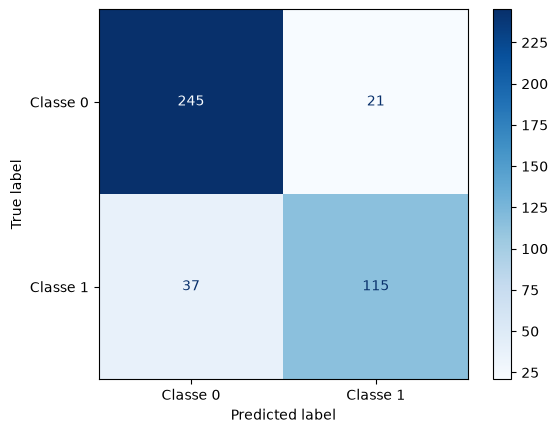

In [201]:
cm = confusion_matrix(y_true, y_pred)

# Plotagem
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Classe 0', 'Classe 1'])
disp.plot(cmap='Blues')